In [2]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("superstore_clean.csv", encoding="utf-8", parse_dates=["order_date"])
print("Dimensions :", df.shape)

Dimensions : (51290, 26)


In [5]:
### 1. Agrégation en série temporelle quotidienne
daily_sales = df.groupby("order_date")["sales"].sum().reset_index()
daily_sales.columns = ["date", "sales"]

daily_sales = (
    daily_sales.set_index("date")
    .asfreq("D", fill_value=0)
    .reset_index()
)

print("Nombre de jours :", len(daily_sales))
print("Jours sans aucune vente :", (daily_sales["sales"] == 0).sum())
daily_sales.head()


Nombre de jours : 1461
Jours sans aucune vente : 31


,date,sales
0,2011-01-01,808
1,2011-01-02,314
2,2011-01-03,4502
3,2011-01-04,2809
4,2011-01-05,3664


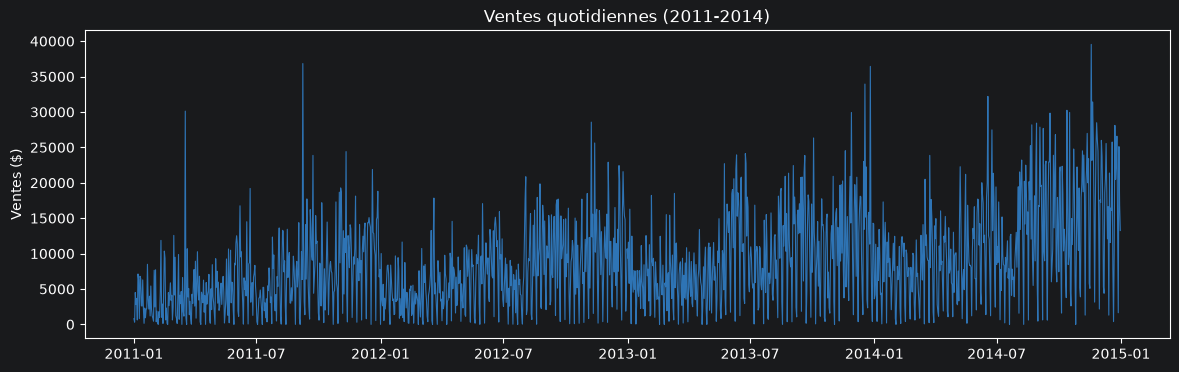

In [4]:
### 2. Visualisation de la série brute

plt.figure(figsize=(14, 4))
plt.plot(daily_sales["date"], daily_sales["sales"], linewidth=0.8, color="#2E74B5")
plt.title("Ventes quotidiennes (2011-2014)")
plt.ylabel("Ventes ($)")
plt.show()

In [6]:
### 3. Feature engineering temporel
daily_sales["year"] = daily_sales["date"].dt.year
daily_sales["month"] = daily_sales["date"].dt.month
daily_sales["day"] = daily_sales["date"].dt.day
daily_sales["day_of_week"] = daily_sales["date"].dt.dayofweek  # 0=lundi
daily_sales["week_of_year"] = daily_sales["date"].dt.isocalendar().week.astype(int)
daily_sales["quarter"] = daily_sales["date"].dt.quarter
daily_sales["is_year_end"] = daily_sales["month"].isin([11, 12]).astype(int)

daily_sales.head()


,date,sales,year,month,day,day_of_week,week_of_year,quarter,is_year_end
0,2011-01-01,808,2011,1,1,5,52,1,0
1,2011-01-02,314,2011,1,2,6,52,1,0
2,2011-01-03,4502,2011,1,3,0,1,1,0
3,2011-01-04,2809,2011,1,4,1,1,1,0
4,2011-01-05,3664,2011,1,5,2,1,1,0


In [7]:
#4. Lags — valeurs passées comme features
for lag in [1, 7, 14, 30]:
    daily_sales[f"sales_lag_{lag}"] = daily_sales["sales"].shift(lag)

daily_sales[["date", "sales", "sales_lag_1", "sales_lag_7", "sales_lag_30"]].iloc[25:32]


,date,sales,sales_lag_1,sales_lag_7,sales_lag_30
25,2011-01-26,5422,1192.0,2054.0,NaN
26,2011-01-27,2166,5422.0,2288.0,NaN
27,2011-01-28,1208,2166.0,8486.0,NaN
28,2011-01-29,910,1208.0,3563.0,NaN
29,2011-01-30,455,910.0,2163.0,NaN
30,2011-01-31,7643,455.0,3983.0,808.0
31,2011-02-01,2457,7643.0,1192.0,314.0


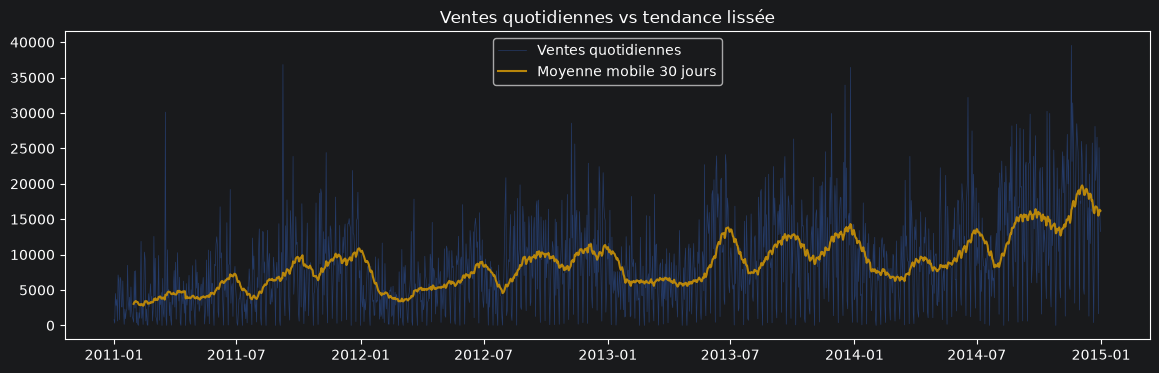

In [8]:
#5. Moyenne mobile — lisser la tendance
daily_sales["sales_rolling_7"] = daily_sales["sales"].rolling(window=7).mean()
daily_sales["sales_rolling_30"] = daily_sales["sales"].rolling(window=30).mean()

plt.figure(figsize=(14, 4))
plt.plot(daily_sales["date"], daily_sales["sales"], linewidth=0.5, alpha=0.4, label="Ventes quotidiennes")
plt.plot(daily_sales["date"], daily_sales["sales_rolling_30"], linewidth=1.5, color="#B8860B", label="Moyenne mobile 30 jours")
plt.legend()
plt.title("Ventes quotidiennes vs tendance lissée")
plt.show()

In [9]:
#6. Nettoyage final et sauvegarde
before = len(daily_sales)
daily_sales_clean = daily_sales.dropna().reset_index(drop=True)
after = len(daily_sales_clean)

print(f"Lignes retirées (valeurs manquantes en début de série) : {before - after}")
print(f"Lignes restantes, prêtes pour l'entraînement : {after}")

daily_sales_clean.to_csv("sales_timeseries_features.csv", index=False)
print("\nFichier sauvegardé : sales_timeseries_features.csv")
daily_sales_clean.head()

Lignes retirées (valeurs manquantes en début de série) : 30
Lignes restantes, prêtes pour l'entraînement : 1431

Fichier sauvegardé : sales_timeseries_features.csv


,date,sales,year,month,day,day_of_week,week_of_year,quarter,is_year_end,sales_lag_1,sales_lag_7,sales_lag_14,sales_lag_30,sales_rolling_7,sales_rolling_30
0,2011-01-31,7643,2011,1,31,0,5,1,0,455.0,3983.0,2310.0,808.0,2713.714286,3269.800000
1,2011-02-01,2457,2011,2,1,1,5,1,0,7643.0,1192.0,932.0,314.0,2894.428571,3341.233333
2,2011-02-02,7712,2011,2,2,2,5,1,0,2457.0,5422.0,2054.0,4502.0,3221.571429,3448.233333
3,2011-02-03,366,2011,2,3,3,5,1,0,7712.0,2166.0,2288.0,2809.0,2964.428571,3366.800000
4,2011-02-04,1866,2011,2,4,4,5,1,0,366.0,1208.0,8486.0,3664.0,3058.428571,3306.866667
